In [10]:
#!/usr/bin/env python
# coding: utf-8

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow as pw
import os

--- Configuration & Setup ---

In [12]:
sns.set_theme(style="whitegrid")
output_dir = '../outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

1. Load Data

In [13]:
DATA_PATH = '../data/mercedes_benz_sales_2020_2025_final.parquet'
df = pd.read_parquet(DATA_PATH)
print("Data loaded successfully!")

Data loaded successfully!


2. Preprocessing

In [14]:
def analyze_mercedes_data(file_path):
    categorical_cols = ['Model', 'Fuel Type', 'Region', 'Color', 'Turbo']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')
    df['Price_per_HP'] = df['Base Price (USD)'] / df['Horsepower']

    # --- 3. Analysis & Visuals (FIXED SEABORN CALLS) ---

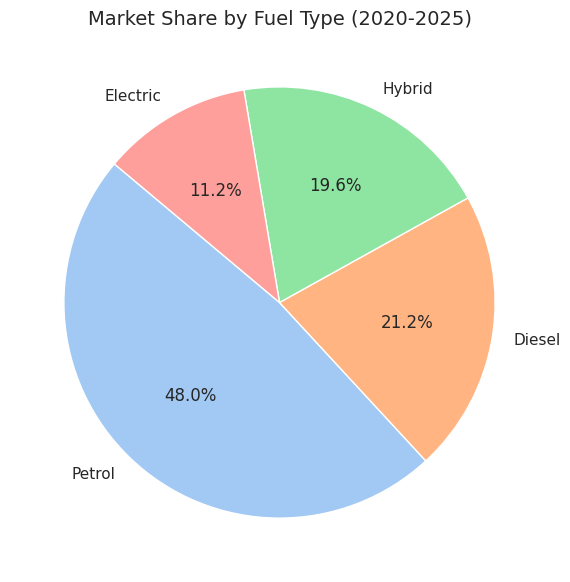

In [15]:
    # Visual 1: Fuel Type Distribution
    plt.figure(figsize=(10, 7))
    fuel_dist = df['Fuel Type'].value_counts()
    plt.pie(fuel_dist, labels=fuel_dist.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Market Share by Fuel Type (2020-2025)', fontsize=14)
    plt.savefig(f'{output_dir}/fuel_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

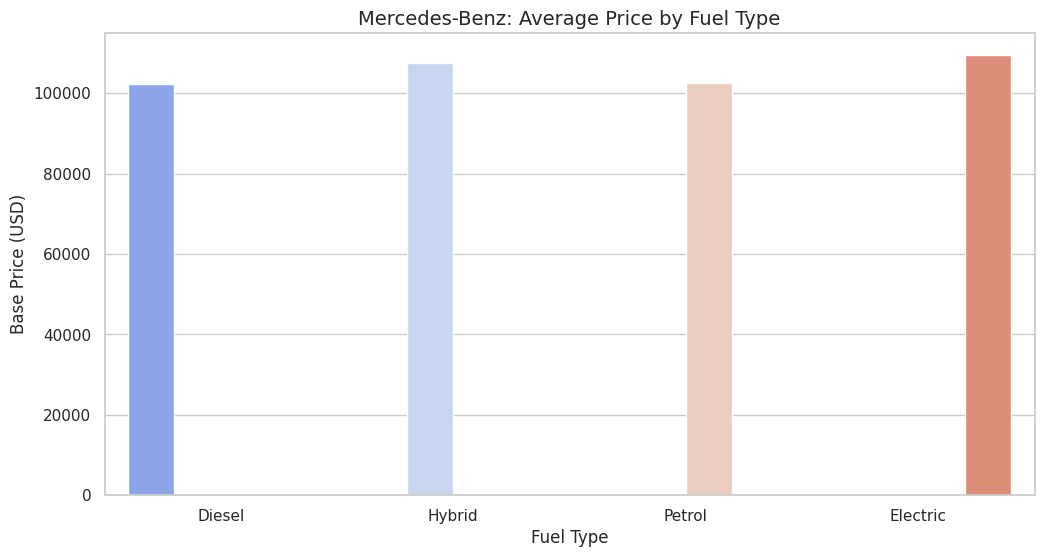

In [16]:
    # Visual 2: Avg Price by Fuel Type (FIXED: added hue and legend=False)
    plt.figure(figsize=(12, 6))
    fuel_summary = df.groupby('Fuel Type', observed=True)['Base Price (USD)'].mean().reset_index()
    sns.barplot(data=fuel_summary, x='Fuel Type', y='Base Price (USD)', hue='Fuel Type', palette='coolwarm', legend=False)
    plt.title("Mercedes-Benz: Average Price by Fuel Type", fontsize=14)
    plt.savefig(f'{output_dir}/avg_price_by_fuel.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

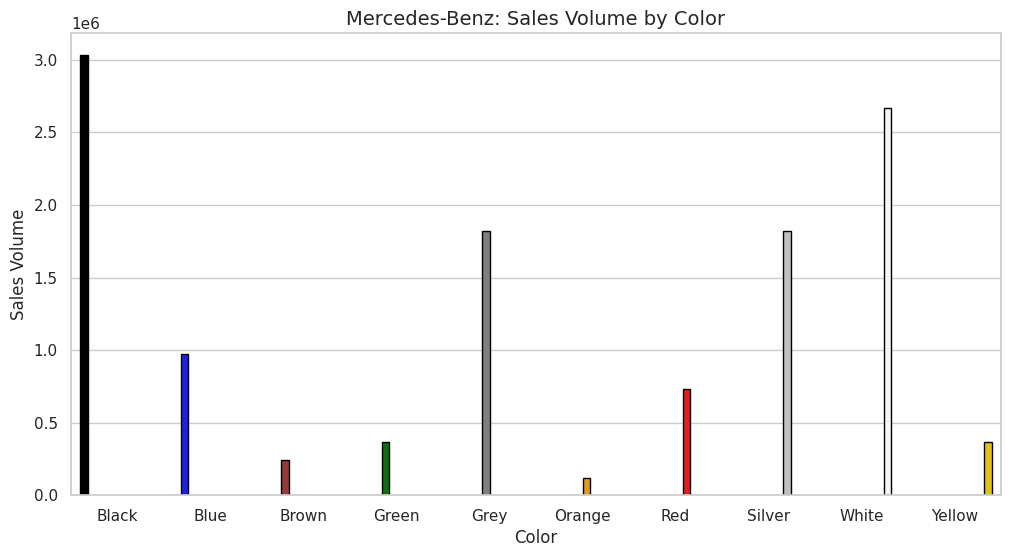

In [17]:
    # Visual 3: Color Popularity (FIXED: added hue and legend=False)
    plt.figure(figsize=(12, 6))
    color_sales = df.groupby('Color', observed=True)['Sales Volume'].sum().sort_values(ascending=False).reset_index()
    color_map = {
        'Black': 'black', 'White': 'whitesmoke', 'Grey': 'grey', 'Silver': 'silver', 
        'Blue': 'blue', 'Red': 'red', 'Yellow': 'gold', 'Green': 'green', 
        'Orange': 'orange', 'Brown': 'brown'
    }
    sns.barplot(data=color_sales, x='Color', y='Sales Volume', hue='Color', palette=color_map, edgecolor='black', legend=False)
    plt.title('Mercedes-Benz: Sales Volume by Color', fontsize=14)
    plt.savefig(f'{output_dir}/color_popularity_final.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

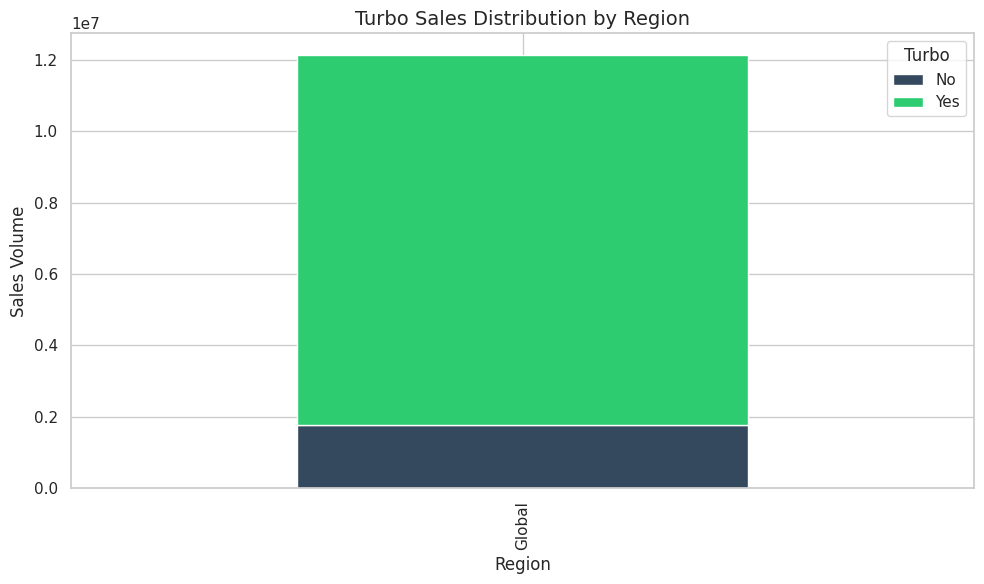

In [18]:
    # Visual 4: Turbo by Region
    region_turbo = df.groupby(['Region', 'Turbo'], observed=True)['Sales Volume'].sum().unstack()
    region_turbo.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#34495e', '#2ecc71'])
    plt.title('Turbo Sales Distribution by Region', fontsize=14)
    plt.ylabel('Sales Volume')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/turbo_regional_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

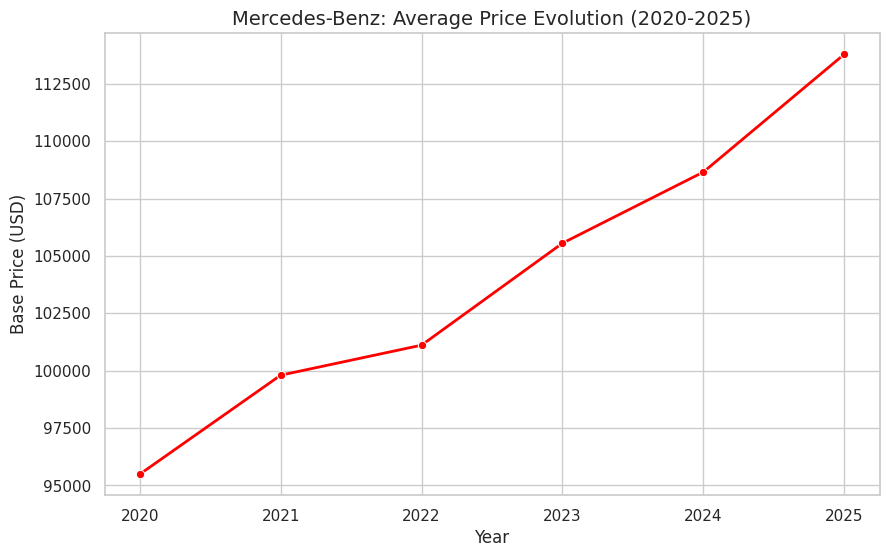

In [19]:
    # Visual 5: Price Evolution
    plt.figure(figsize=(10, 6))
    price_evolution = df.groupby('Year')['Base Price (USD)'].mean().reset_index()
    sns.lineplot(data=price_evolution, x='Year', y='Base Price (USD)', marker='o', color='red', linewidth=2)
    plt.title('Mercedes-Benz: Average Price Evolution (2020-2025)', fontsize=14)
    plt.savefig(f'{output_dir}/price_trend_overall.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

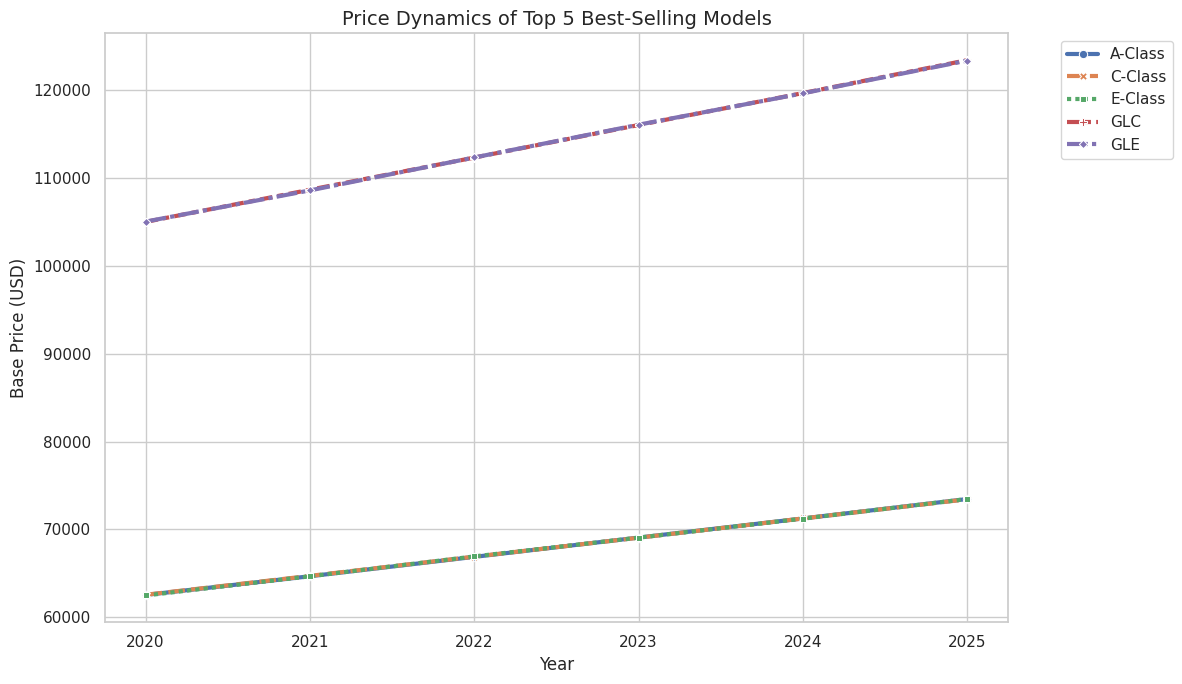

In [20]:
    # Visual 6: Top 5 Trends
    top_5_names = df.groupby('Model', observed=True)['Sales Volume'].sum().nlargest(5).index
    df_top5 = df[df['Model'].isin(top_5_names)].copy()
    df_top5['Model'] = df_top5['Model'].cat.remove_unused_categories()
    top_5_trends = df_top5.groupby(['Year', 'Model'], observed=True)['Base Price (USD)'].mean().reset_index()
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=top_5_trends, x='Year', y='Base Price (USD)', hue='Model', style='Model', markers=True, linewidth=3)
    plt.title('Price Dynamics of Top 5 Best-Selling Models', fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/top_5_models_trend_final.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

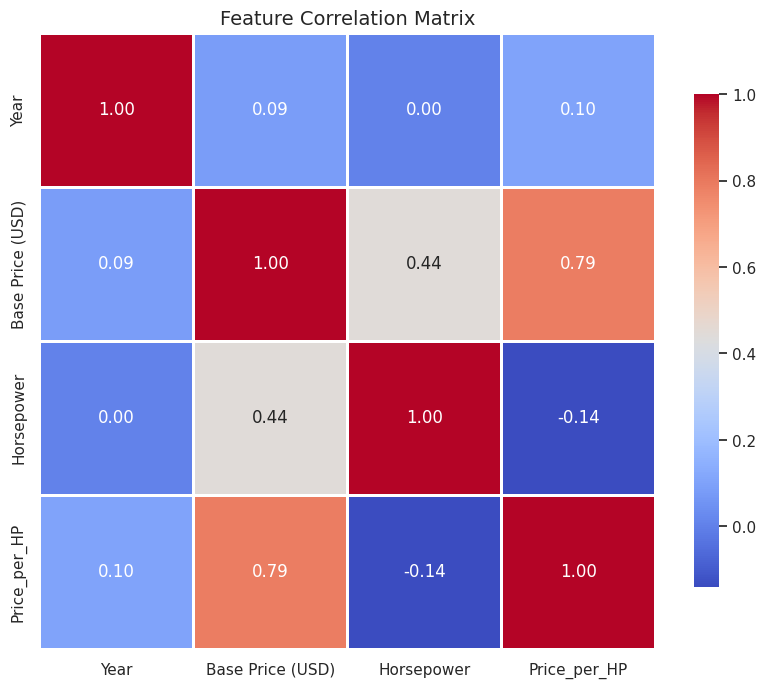

In [21]:
    # Visual 7: Correlation Heatmap
    df['Price_per_HP'] = df['Base Price (USD)'] / df['Horsepower']
    
    plt.figure(figsize=(10, 8))
    cols_to_analyze = ['Year', 'Base Price (USD)', 'Horsepower', 'Price_per_HP']
    corr = df[cols_to_analyze].corr()
    
    sns.heatmap(
        corr, 
        annot=True, 
        cmap='coolwarm', 
        fmt=".2f", 
        linewidths=1, 
        square=True,
        cbar_kws={"shrink": .8}
    )
    
    plt.title('Feature Correlation Matrix', fontsize=14)
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()

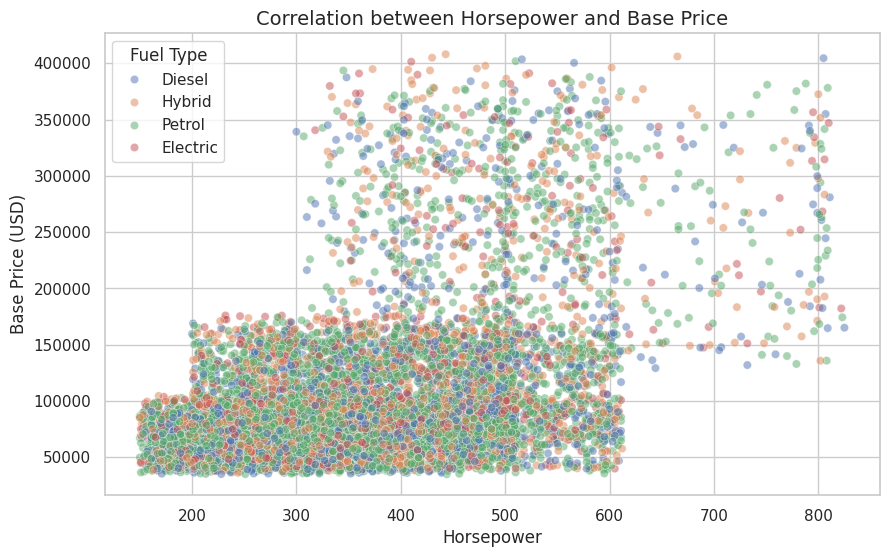

Analysis complete. All plots saved in: ../outputs


In [22]:
    # Visual 8: Horsepower vs Price
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df.sample(10000), x='Horsepower', y='Base Price (USD)', hue='Fuel Type', alpha=0.5)
    plt.title('Correlation between Horsepower and Base Price', fontsize=14)
    plt.savefig(f'{output_dir}/hp_price_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    #plt.close()
    print(f"Analysis complete. All plots saved in: {output_dir}")

## Thank You!
Thank you for taking the time to review this analysis. I hope the insights from the Mercedes-Benz sales data were informative.

**Let's Connect!**
If you have any questions or would like to discuss this project further, feel free to reach out to me on www.linkedin.com/in/seyrananalytics